# Phase 2: Feature Engineering

## Purpose
This notebook constructs the feature set for uncertainty-aware bus ETA prediction using conformal prediction. We engineer features across **four categories**, each motivated by domain knowledge of transit systems and the requirements of our XGBoost base model:

### Feature Categories

1. **Temporal Features**: Hour of day, day of week, weekend indicator, time period classification (peak/off-peak), and cyclical sin/cos encodings. These capture the systematic variation in travel times driven by commuter patterns, traffic congestion cycles, and weekday-weekend differences.

2. **Historical Statistics**: Rolling mean, standard deviation, median, and quantiles computed over a 7-day lookback window, grouped by route/segment, direction, and time period. These provide the model with a "baseline expectation" for current conditions based on recent history.

3. **Spatial / Route Context**: Label-encoded route and direction identifiers, normalized segment position along the route, and total route segment count. These allow the model to learn route-specific and position-specific patterns.

4. **Schedule Deviation / Trip Progress**: Cumulative travel time along a trip, number of segments completed, fraction of route completed, and lag features from preceding segments. These capture within-trip dynamics where early segment behavior is predictive of later segment times.

### Temporal Integrity
**All historical features use strict past-only lookback windows.** For a prediction at time $t$, only data from $[t - 7\text{ days}, t)$ is used to compute historical statistics. This prevents data leakage and ensures that conformal prediction validity is maintained, since the exchangeability assumption underlying conformal prediction requires that training features do not encode future information.

### Thesis Connection
The feature engineering strategy directly supports the three research questions:
- **RQ1**: Historical features with strict temporal boundaries enable honest evaluation of coverage degradation under distribution shift.
- **RQ2**: The same features are used across static and online conformal methods, ensuring fair comparison.
- **RQ3**: Segment-level features (cumulative trip progress, preceding segment lags) enable the segment-level decomposition needed for uncertainty attribution.

In [1]:
# === Imports & Setup ===
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from utils.data_loading import load_cached_dataframe
from utils.feature_engineering import (
    add_temporal_features,
    add_cyclical_time_features,
    add_historical_segment_statistics,
    add_historical_route_statistics,
    add_cumulative_trip_features,
    add_preceding_segment_features,
    add_route_context_features,
    get_feature_names,
)
from utils.temporal_splits import label_temporal_period
from utils.visualization import set_thesis_style

# Apply thesis-quality plotting style
set_thesis_style()

# Paths
PROCESSED_DIR = '../outputs/processed_data/'
FIG_DIR = '../outputs/figures/phase2/'
TABLE_DIR = '../outputs/tables/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print('Phase 2 setup complete.')
print(f'Figure output directory: {os.path.abspath(FIG_DIR)}')
print(f'Table output directory:  {os.path.abspath(TABLE_DIR)}')

Phase 2 setup complete.
Figure output directory: /Users/korayduzgun/Master/Courses/FinalProject/ImplementationV1/outputs/figures/phase2
Table output directory:  /Users/korayduzgun/Master/Courses/FinalProject/ImplementationV1/outputs/tables


---
## 1. Load Cleaned Data

We load the cleaned segment-level and route-level datasets produced by Phase 1 (Data Cleaning). These datasets have already undergone:
- Removal of anomalous dates (Sep 3-4)
- Outlier filtering based on IQR and domain thresholds
- Incomplete trip removal
- Route-level aggregation from segment data

In [2]:
# Load cleaned datasets from Phase 1
segment_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'segment_cleaned.parquet'))
route_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'route_level.parquet'))

# Ensure date columns are proper datetime
segment_df['date'] = pd.to_datetime(segment_df['date'])
route_df['date'] = pd.to_datetime(route_df['date'])

print(f'Segment-level data: {segment_df.shape[0]:,} rows x {segment_df.shape[1]} columns')
print(f'Route-level data:   {route_df.shape[0]:,} rows x {route_df.shape[1]} columns')
print(f'\nSegment date range: {segment_df["date"].min().date()} to {segment_df["date"].max().date()}')
print(f'Route date range:   {route_df["date"].min().date()} to {route_df["date"].max().date()}')
print(f'\nSegment columns: {list(segment_df.columns)}')
print(f'Route columns:   {list(route_df.columns)}')

Segment-level data: 747,798 rows x 20 columns
Route-level data:   19,614 rows x 13 columns

Segment date range: 2024-07-29 to 2024-09-21
Route date range:   2024-07-29 to 2024-09-21

Segment columns: ['date', 'deviceid', 'direction', 'segment', 'start_point', 'end_point', 'start_time', 'run_time_in_seconds', 'dwell_time_in_seconds', 'arrival_time', 'departure_time', 'trip_id', 'device_guid', 'start_guid', 'end_guid', 'route_id', 'route_short_name', 'route_long_name', 'total_segment_time', 'temporal_period']
Route columns:   ['trip_id', 'total_run_time_seconds', 'total_dwell_time_seconds', 'num_segments', 'direction', 'date', 'route_id', 'route_short_name', 'deviceid', 'departure_time', 'total_travel_time_seconds', 'route_dir', 'temporal_period']


---
## 2. Temporal Features

Temporal features capture the systematic variation in travel times driven by time-of-day, day-of-week, and peak/off-peak patterns. These are among the most predictive features for bus ETA models because transit travel times are strongly governed by recurring traffic patterns.

**Features extracted:**
- `hour_of_day` (0-23): Integer hour for direct use and interaction effects
- `minute_of_day` (0-1439): Fine-grained time resolution
- `day_of_week` (0=Monday to 6=Sunday): Captures weekly cyclical patterns
- `is_weekend` (0/1): Binary indicator for weekend vs weekday behavior
- `time_period`: Categorical classification into early_morning, morning_peak, midday, evening_peak, evening, night
- `week_number`: Relative week number within the dataset (used for temporal period labeling)

In [3]:
# Add temporal features to both datasets
segment_df = add_temporal_features(segment_df)
route_df = add_temporal_features(route_df)

print('Temporal features added to both datasets.')
print(f'\nSegment columns after temporal features: {segment_df.shape[1]}')
print(f'Route columns after temporal features:   {route_df.shape[1]}')

# Show distribution of time_period categories
print('\n=== Time Period Distribution (Segment-Level) ===')
tp_dist = segment_df['time_period'].value_counts().sort_index()
tp_pct = (tp_dist / tp_dist.sum() * 100).round(1)
tp_summary = pd.DataFrame({'Count': tp_dist, 'Percentage': tp_pct})
display(tp_summary)

print('\n=== Time Period Distribution (Route-Level) ===')
tp_dist_r = route_df['time_period'].value_counts().sort_index()
tp_pct_r = (tp_dist_r / tp_dist_r.sum() * 100).round(1)
tp_summary_r = pd.DataFrame({'Count': tp_dist_r, 'Percentage': tp_pct_r})
display(tp_summary_r)

# Sample values
print('\n=== Sample Temporal Features (first 5 rows) ===')
display(segment_df[['date', 'hour_of_day', 'minute_of_day', 'day_of_week', 'is_weekend', 'time_period']].head())

Temporal features added to both datasets.

Segment columns after temporal features: 26
Route columns after temporal features:   19

=== Time Period Distribution (Segment-Level) ===


,Count,Percentage
time_period,,
early_morning,21256,2.8
evening,119408,16.0
evening_peak,130271,17.4
midday,305824,40.9
morning_peak,157174,21.0
night,13865,1.9



=== Time Period Distribution (Route-Level) ===


,Count,Percentage
time_period,,
early_morning,1569,8.0
evening,2584,13.2
evening_peak,3145,16.0
midday,7761,39.6
morning_peak,4527,23.1
night,28,0.1



=== Sample Temporal Features (first 5 rows) ===


,date,hour_of_day,minute_of_day,day_of_week,is_weekend,time_period
0,2024-08-01,16,1004,3,0,evening_peak
1,2024-09-11,16,976,2,0,evening_peak
2,2024-09-11,18,1102,2,0,evening_peak
3,2024-09-11,18,1121,2,0,evening_peak
4,2024-08-29,21,1280,3,0,evening


---
## 3. Cyclical Time Encodings

Raw integer encodings of hour and day-of-week create an artificial discontinuity: hour 23 and hour 0 are numerically distant but temporally adjacent. **Cyclical sin/cos encodings** solve this by projecting each value onto a unit circle:

$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad \text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

$$\text{dow\_sin} = \sin\left(\frac{2\pi \cdot \text{day\_of\_week}}{7}\right), \quad \text{dow\_cos} = \cos\left(\frac{2\pi \cdot \text{day\_of\_week}}{7}\right)$$

This ensures that the Euclidean distance between encodings respects temporal proximity (e.g., Sunday and Monday are close). While tree-based models like XGBoost can learn arbitrary splits on integer features, cyclical encodings help with gradient-based optimization and provide a more natural representation for any downstream models.

In [4]:
# Add cyclical time encodings
segment_df = add_cyclical_time_features(segment_df)
route_df = add_cyclical_time_features(route_df)

print('Cyclical time features added.')

# Show sample values to verify correctness
sample_hours = segment_df[['hour_of_day', 'hour_sin', 'hour_cos']].drop_duplicates().sort_values('hour_of_day')
print('\n=== Cyclical Encoding Samples (Hour) ===')
display(sample_hours.head(10))

sample_dow = segment_df[['day_of_week', 'dow_sin', 'dow_cos']].drop_duplicates().sort_values('day_of_week')
print('\n=== Cyclical Encoding Samples (Day of Week) ===')
display(sample_dow)

# Verify: sin^2 + cos^2 should equal 1
hour_check = (segment_df['hour_sin']**2 + segment_df['hour_cos']**2).mean()
dow_check = (segment_df['dow_sin']**2 + segment_df['dow_cos']**2).mean()
print(f'\nVerification (sin^2 + cos^2 = 1):')
print(f'  Hour encodings: {hour_check:.6f}')
print(f'  DoW encodings:  {dow_check:.6f}')

Cyclical time features added.

=== Cyclical Encoding Samples (Hour) ===


,hour_of_day,hour_sin,hour_cos
380554,4,8.660254e-01,5.000000e-01
10385,5,9.659258e-01,2.588190e-01
33,6,1.000000e+00,6.123234e-17
7,7,9.659258e-01,-2.588190e-01
8,8,8.660254e-01,-5.000000e-01
9,9,7.071068e-01,-7.071068e-01
10,10,5.000000e-01,-8.660254e-01
24,11,2.588190e-01,-9.659258e-01
23,12,1.224647e-16,-1.000000e+00
37,13,-2.588190e-01,-9.659258e-01



=== Cyclical Encoding Samples (Day of Week) ===


,day_of_week,dow_sin,dow_cos
33,0,0.000000,1.000000
37,1,0.781831,0.623490
1,2,0.974928,-0.222521
0,3,0.433884,-0.900969
7,4,-0.433884,-0.900969
20,5,-0.974928,-0.222521
29,6,-0.781831,0.623490



Verification (sin^2 + cos^2 = 1):
  Hour encodings: 1.000000
  DoW encodings:  1.000000


---
## 4. Historical Statistics - Route-Level

Historical statistics provide the model with a "baseline expectation" for the current prediction context. For each combination of (route, direction, time_period) and each date, we compute rolling statistics from the **previous 7 days only**.

**Features computed:**
- `hist_route_mean`: Mean total travel time from past 7 days for this (route, direction, time_period)
- `hist_route_std`: Standard deviation (captures recent variability)
- `hist_route_median`: Median (robust to outliers)
- `hist_route_q25`, `hist_route_q75`: 25th and 75th percentiles (captures spread)
- `hist_route_count`: Number of historical observations (confidence indicator)

**Temporal Integrity:** The 7-day lookback is strictly past-only. For a prediction on date $d$, only data from $[d-7, d)$ is used. For the first week of the dataset (when less than 7 days of history exist), we fall back to global mean statistics as an imputation strategy. This is noted in the thesis methodology as a conservative design choice that may slightly increase uncertainty for early predictions.

In [5]:
# Add historical route-level statistics with 7-day lookback
print('Computing route-level historical statistics (7-day lookback)...')
print('This may take a few minutes for large datasets.\n')

route_df = add_historical_route_statistics(route_df, lookback_days=7)

print('Route-level historical features added.')
print(f'Route columns after historical features: {route_df.shape[1]}')

# Show sample
hist_route_cols = ['hist_route_mean', 'hist_route_std', 'hist_route_median',
                   'hist_route_q25', 'hist_route_q75', 'hist_route_count']
print('\n=== Sample Historical Route Features ===')
display(route_df[['date', 'time_period'] + hist_route_cols].head(10))

# Check for NaN values
print('\n=== NaN Check for Historical Route Features ===')
nan_counts = route_df[hist_route_cols].isnull().sum()
print(nan_counts)

if nan_counts.sum() == 0:
    print('\nNo NaN values remain. Global mean fallback was applied for the first week.')
else:
    print(f'\nWarning: {nan_counts.sum()} NaN values remain. Investigating...')

# Show statistics for the first week (global fallback) vs later weeks
first_week = route_df[route_df['date'] < pd.Timestamp('2024-08-05')]
later_weeks = route_df[route_df['date'] >= pd.Timestamp('2024-08-05')]
print(f'\nFirst week hist_route_count mean: {first_week["hist_route_count"].mean():.1f} (global fallback)')
print(f'Later weeks hist_route_count mean: {later_weeks["hist_route_count"].mean():.1f} (actual lookback)')

Computing route-level historical statistics (7-day lookback)...
This may take a few minutes for large datasets.

Route-level historical features added.
Route columns after historical features: 29

=== Sample Historical Route Features ===


,date,time_period,hist_route_mean,hist_route_std,hist_route_median,hist_route_q25,hist_route_q75,hist_route_count
0,2024-07-29,early_morning,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
1,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
2,2024-07-29,evening_peak,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
3,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
4,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
5,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
6,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
7,2024-07-29,evening_peak,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
8,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0
9,2024-07-29,midday,5029.098705,1686.269118,5029.098705,4274.733899,5783.463511,0.0



=== NaN Check for Historical Route Features ===
hist_route_mean      0
hist_route_std       0
hist_route_median    0
hist_route_q25       0
hist_route_q75       0
hist_route_count     0
dtype: int64

No NaN values remain. Global mean fallback was applied for the first week.

First week hist_route_count mean: 46.0 (global fallback)
Later weeks hist_route_count mean: 114.2 (actual lookback)


---
## 5. Historical Statistics - Segment-Level

The same 7-day lookback strategy is applied at the segment level, but with finer granularity. For each combination of (segment, direction, time_period) and each date, we compute rolling statistics from the previous 7 days.

**Features computed:**
- `hist_seg_mean`, `hist_seg_std`, `hist_seg_median`: Central tendency and variability for this specific segment
- `hist_seg_q25`, `hist_seg_q75`: Spread indicators
- `hist_seg_count`: Number of historical observations

**Thesis Connection (RQ3):** Segment-level historical statistics are critical for the segment-level model. They capture segment-specific behavior (e.g., a segment near a busy intersection consistently having higher and more variable run times) that drives uncertainty decomposition.

In [6]:
# Add historical segment-level statistics with 7-day lookback
print('Computing segment-level historical statistics (7-day lookback)...')
print('This may take several minutes due to the larger number of groups.\n')

segment_df = add_historical_segment_statistics(segment_df, lookback_days=7)

print('Segment-level historical features added.')
print(f'Segment columns after historical features: {segment_df.shape[1]}')

# Show sample
hist_seg_cols = ['hist_seg_mean', 'hist_seg_std', 'hist_seg_median',
                 'hist_seg_q25', 'hist_seg_q75', 'hist_seg_count']
print('\n=== Sample Historical Segment Features ===')
display(segment_df[['date', 'segment', 'direction', 'time_period'] + hist_seg_cols].head(10))

# Check for NaN values
print('\n=== NaN Check for Historical Segment Features ===')
nan_counts_seg = segment_df[hist_seg_cols].isnull().sum()
print(nan_counts_seg)

if nan_counts_seg.sum() == 0:
    print('\nNo NaN values remain. Global mean fallback was applied for the first week.')
else:
    print(f'\nWarning: {nan_counts_seg.sum()} NaN values remain.')

Computing segment-level historical statistics (7-day lookback)...
This may take several minutes due to the larger number of groups.

Segment-level historical features added.
Segment columns after historical features: 36

=== Sample Historical Segment Features ===


,date,segment,direction,time_period,hist_seg_mean,hist_seg_std,hist_seg_median,hist_seg_q25,hist_seg_q75,hist_seg_count
0,2024-07-29,1,1,evening_peak,910.841785,852.762949,661.0,774.215517,1047.468053,0.0
1,2024-07-29,1,1,midday,1455.274106,1015.688314,1848.0,1236.982990,1673.565222,0.0
2,2024-07-29,1,1,early_morning,239.490486,596.572000,20.0,203.566913,275.414059,0.0
3,2024-07-29,1,1,early_morning,239.490486,596.572000,20.0,203.566913,275.414059,0.0
4,2024-07-29,1,1,evening,238.152191,321.717253,93.0,202.429362,273.875019,0.0
5,2024-07-29,1,1,midday,1455.274106,1015.688314,1848.0,1236.982990,1673.565222,0.0
6,2024-07-29,1,1,morning_peak,625.129487,730.015010,346.5,531.360064,718.898910,0.0
7,2024-07-29,1,1,early_morning,239.490486,596.572000,20.0,203.566913,275.414059,0.0
8,2024-07-29,1,1,early_morning,239.490486,596.572000,20.0,203.566913,275.414059,0.0
9,2024-07-29,1,1,early_morning,239.490486,596.572000,20.0,203.566913,275.414059,0.0



=== NaN Check for Historical Segment Features ===
hist_seg_mean      0
hist_seg_std       0
hist_seg_median    0
hist_seg_q25       0
hist_seg_q75       0
hist_seg_count     0
dtype: int64

No NaN values remain. Global mean fallback was applied for the first week.


---
## Temporal Integrity Note

> **All historical features use strict past-only lookback.** For a prediction at time $t$, only data from $[t - 7\text{ days}, t)$ is used. This prevents data leakage and ensures conformal prediction validity.
>
> Specifically:
> - The historical mean/std/median for date $d$ is computed from data in $[d-7, d)$, never including day $d$ itself.
> - For the first week (when $<7$ days of history exist), we fall back to global statistics computed over the entire training set. This is documented as a conservative choice.
> - The `hist_*_count` feature allows the model to learn that early-period predictions have less historical support, potentially increasing uncertainty.
>
> This design is critical for the thesis because conformal prediction assumes exchangeability between calibration and test data. If features were computed using future data, the calibration residuals would be artificially optimistic, invalidating coverage guarantees.

---
## 6. Cumulative Trip Features (Segment-Level Only)

For the segment-level model, we add features that capture the **within-trip progression**. These features allow the model to condition on how the trip has progressed so far, which is particularly valuable for mid-route predictions.

**Features added:**
- `cumulative_time_so_far`: Sum of total_segment_time for all preceding segments (exclusive of current)
- `segments_completed`: Count of segments already traversed (0 for first segment)
- `fraction_route_completed`: Proportion of the route already completed (0.0 to ~1.0)

**Thesis Connection (RQ3):** These features encode the position-dependent nature of uncertainty. Segments later in a trip have the advantage of observed upstream behavior, which can reduce prediction uncertainty. This directly supports the uncertainty attribution analysis.

In [7]:
# Add cumulative trip features (segment-level only)
segment_df = add_cumulative_trip_features(segment_df)

print('Cumulative trip features added.')
print(f'Segment columns after cumulative features: {segment_df.shape[1]}')

# Show sample for a single trip
sample_trip_id = segment_df['trip_id'].iloc[0]
sample_trip = segment_df[segment_df['trip_id'] == sample_trip_id].sort_values('segment')

print(f'\n=== Cumulative Features for Trip {sample_trip_id} ===')
display(sample_trip[['segment', 'run_time_in_seconds', 'dwell_time_in_seconds',
                     'cumulative_time_so_far', 'segments_completed',
                     'fraction_route_completed']].head(15))

# Verify: first segment should have cumulative_time_so_far = 0
first_segs = segment_df.groupby('trip_id').first()
print(f'\nVerification: First segment cumulative_time_so_far == 0: '
      f'{(first_segs["cumulative_time_so_far"] == 0).all()}')
print(f'Verification: First segment segments_completed == 0: '
      f'{(first_segs["segments_completed"] == 0).all()}')

Cumulative trip features added.
Segment columns after cumulative features: 39

=== Cumulative Features for Trip 1 ===


,segment,run_time_in_seconds,dwell_time_in_seconds,cumulative_time_so_far,segments_completed,fraction_route_completed
0,2,215.0,37.0,0.0,0,0.000000
1,4,54.0,12.0,252.0,1,0.023810
2,5,64.0,14.0,318.0,2,0.047619
3,6,209.0,5.0,396.0,3,0.071429
4,7,108.0,19.0,610.0,4,0.095238
5,8,103.0,31.0,737.0,5,0.119048
6,9,57.0,25.0,871.0,6,0.142857
7,10,94.0,31.0,953.0,7,0.166667
8,11,95.0,29.0,1078.0,8,0.190476
9,12,52.0,39.0,1202.0,9,0.214286



Verification: First segment cumulative_time_so_far == 0: True
Verification: First segment segments_completed == 0: True


---
## 7. Preceding Segment Features (Segment-Level Only)

Lag features from preceding segments capture the **autoregressive structure** of travel times within a trip. If the immediately preceding segment took longer than expected, it is likely that traffic conditions will persist into the current segment.

**Features added:**
- `prev_seg_run_time`: Run time of segment $(n-1)$
- `prev_seg_dwell_time`: Dwell time of segment $(n-1)$
- `prev_2_seg_avg_run_time`: Average run time of segments $(n-1)$ and $(n-2)$
- `prev_3_seg_avg_run_time`: Average run time of segments $(n-1)$, $(n-2)$, and $(n-3)$

For the first segment(s) of each trip where lag values are unavailable, we impute with the column mean. This conservative approach avoids introducing bias while providing a reasonable default.

In [8]:
# Add preceding segment lag features (segment-level only)
segment_df = add_preceding_segment_features(segment_df)

print('Preceding segment features added.')
print(f'Segment columns after lag features: {segment_df.shape[1]}')

# Show sample for the same trip
lag_cols = ['prev_seg_run_time', 'prev_seg_dwell_time',
            'prev_2_seg_avg_run_time', 'prev_3_seg_avg_run_time']
sample_trip = segment_df[segment_df['trip_id'] == sample_trip_id].sort_values('segment')

print(f'\n=== Lag Features for Trip {sample_trip_id} ===')
display(sample_trip[['segment', 'run_time_in_seconds'] + lag_cols].head(10))

# Check for NaN values in lag features
print('\n=== NaN Check for Lag Features ===')
print(segment_df[lag_cols].isnull().sum())

Preceding segment features added.
Segment columns after lag features: 43

=== Lag Features for Trip 1 ===


,segment,run_time_in_seconds,prev_seg_run_time,prev_seg_dwell_time,prev_2_seg_avg_run_time,prev_3_seg_avg_run_time
0,2,215.0,94.372022,94.372022,94.372022,94.372022
1,4,54.0,215.000000,37.000000,94.372022,94.372022
2,5,64.0,54.000000,12.000000,134.500000,94.372022
3,6,209.0,64.000000,14.000000,59.000000,111.000000
4,7,108.0,209.000000,5.000000,136.500000,109.000000
5,8,103.0,108.000000,19.000000,158.500000,127.000000
6,9,57.0,103.000000,31.000000,105.500000,140.000000
7,10,94.0,57.000000,25.000000,80.000000,89.333333
8,11,95.0,94.000000,31.000000,75.500000,84.666667
9,12,52.0,95.000000,29.000000,94.500000,82.000000



=== NaN Check for Lag Features ===
prev_seg_run_time          0
prev_seg_dwell_time        0
prev_2_seg_avg_run_time    0
prev_3_seg_avg_run_time    0
dtype: int64


---
## 8. Route / Spatial Context Features

Spatial context features encode the structural properties of the route and the current position along it. These allow the model to learn route-specific patterns without requiring separate models for each route.

**Features added:**
- `route_id_encoded`: Integer label encoding of the route name (e.g., Route 10 -> 0, Route 12 -> 1, Route 46 -> 2)
- `direction_encoded`: Binary direction indicator (0 or 1)
- `segment_number_normalized`: Segment position normalized to [0, 1] range (segment-level only)
- `total_route_segments`: Total number of segments in this trip's route (segment-level only)

In [9]:
# Add route context features to both datasets
segment_df = add_route_context_features(segment_df)
route_df = add_route_context_features(route_df)

print('Route context features added to both datasets.')
print(f'Segment columns after route context: {segment_df.shape[1]}')
print(f'Route columns after route context:   {route_df.shape[1]}')

# Show route encoding mapping
if 'route_short_name' in segment_df.columns:
    route_encoding = segment_df[['route_short_name', 'route_id_encoded']].drop_duplicates().sort_values('route_id_encoded')
    print('\n=== Route Encoding ===')
    display(route_encoding)

# Show direction encoding
if 'direction' in segment_df.columns:
    dir_encoding = segment_df[['direction', 'direction_encoded']].drop_duplicates().sort_values('direction_encoded')
    print('\n=== Direction Encoding ===')
    display(dir_encoding)

# Show segment normalization sample
if 'segment_number_normalized' in segment_df.columns:
    sample = segment_df[segment_df['trip_id'] == sample_trip_id].sort_values('segment')
    print('\n=== Segment Normalization (sample trip) ===')
    display(sample[['segment', 'segment_number_normalized', 'total_route_segments']].head(10))

Route context features added to both datasets.
Segment columns after route context: 47
Route columns after route context:   31

=== Route Encoding ===


,route_short_name,route_id_encoded
81,10,0
116,12,1
0,46,2



=== Direction Encoding ===


,direction,direction_encoded
81,1,0
0,2,1



=== Segment Normalization (sample trip) ===


,segment,segment_number_normalized,total_route_segments
0,2,0.047619,42
1,4,0.095238,42
2,5,0.119048,42
3,6,0.142857,42
4,7,0.166667,42
5,8,0.190476,42
6,9,0.214286,42
7,10,0.238095,42
8,11,0.261905,42
9,12,0.285714,42


---
## Plot P2.1: Feature Correlation Matrix (Route-Level)

**Thesis Connection:** Understanding feature correlations helps identify redundancy and multicollinearity. While XGBoost is generally robust to correlated features, extreme correlations (e.g., between `hist_route_mean` and `hist_route_median`) suggest that the model may not benefit from both. This plot also validates that historical features are meaningfully correlated with the target variable.

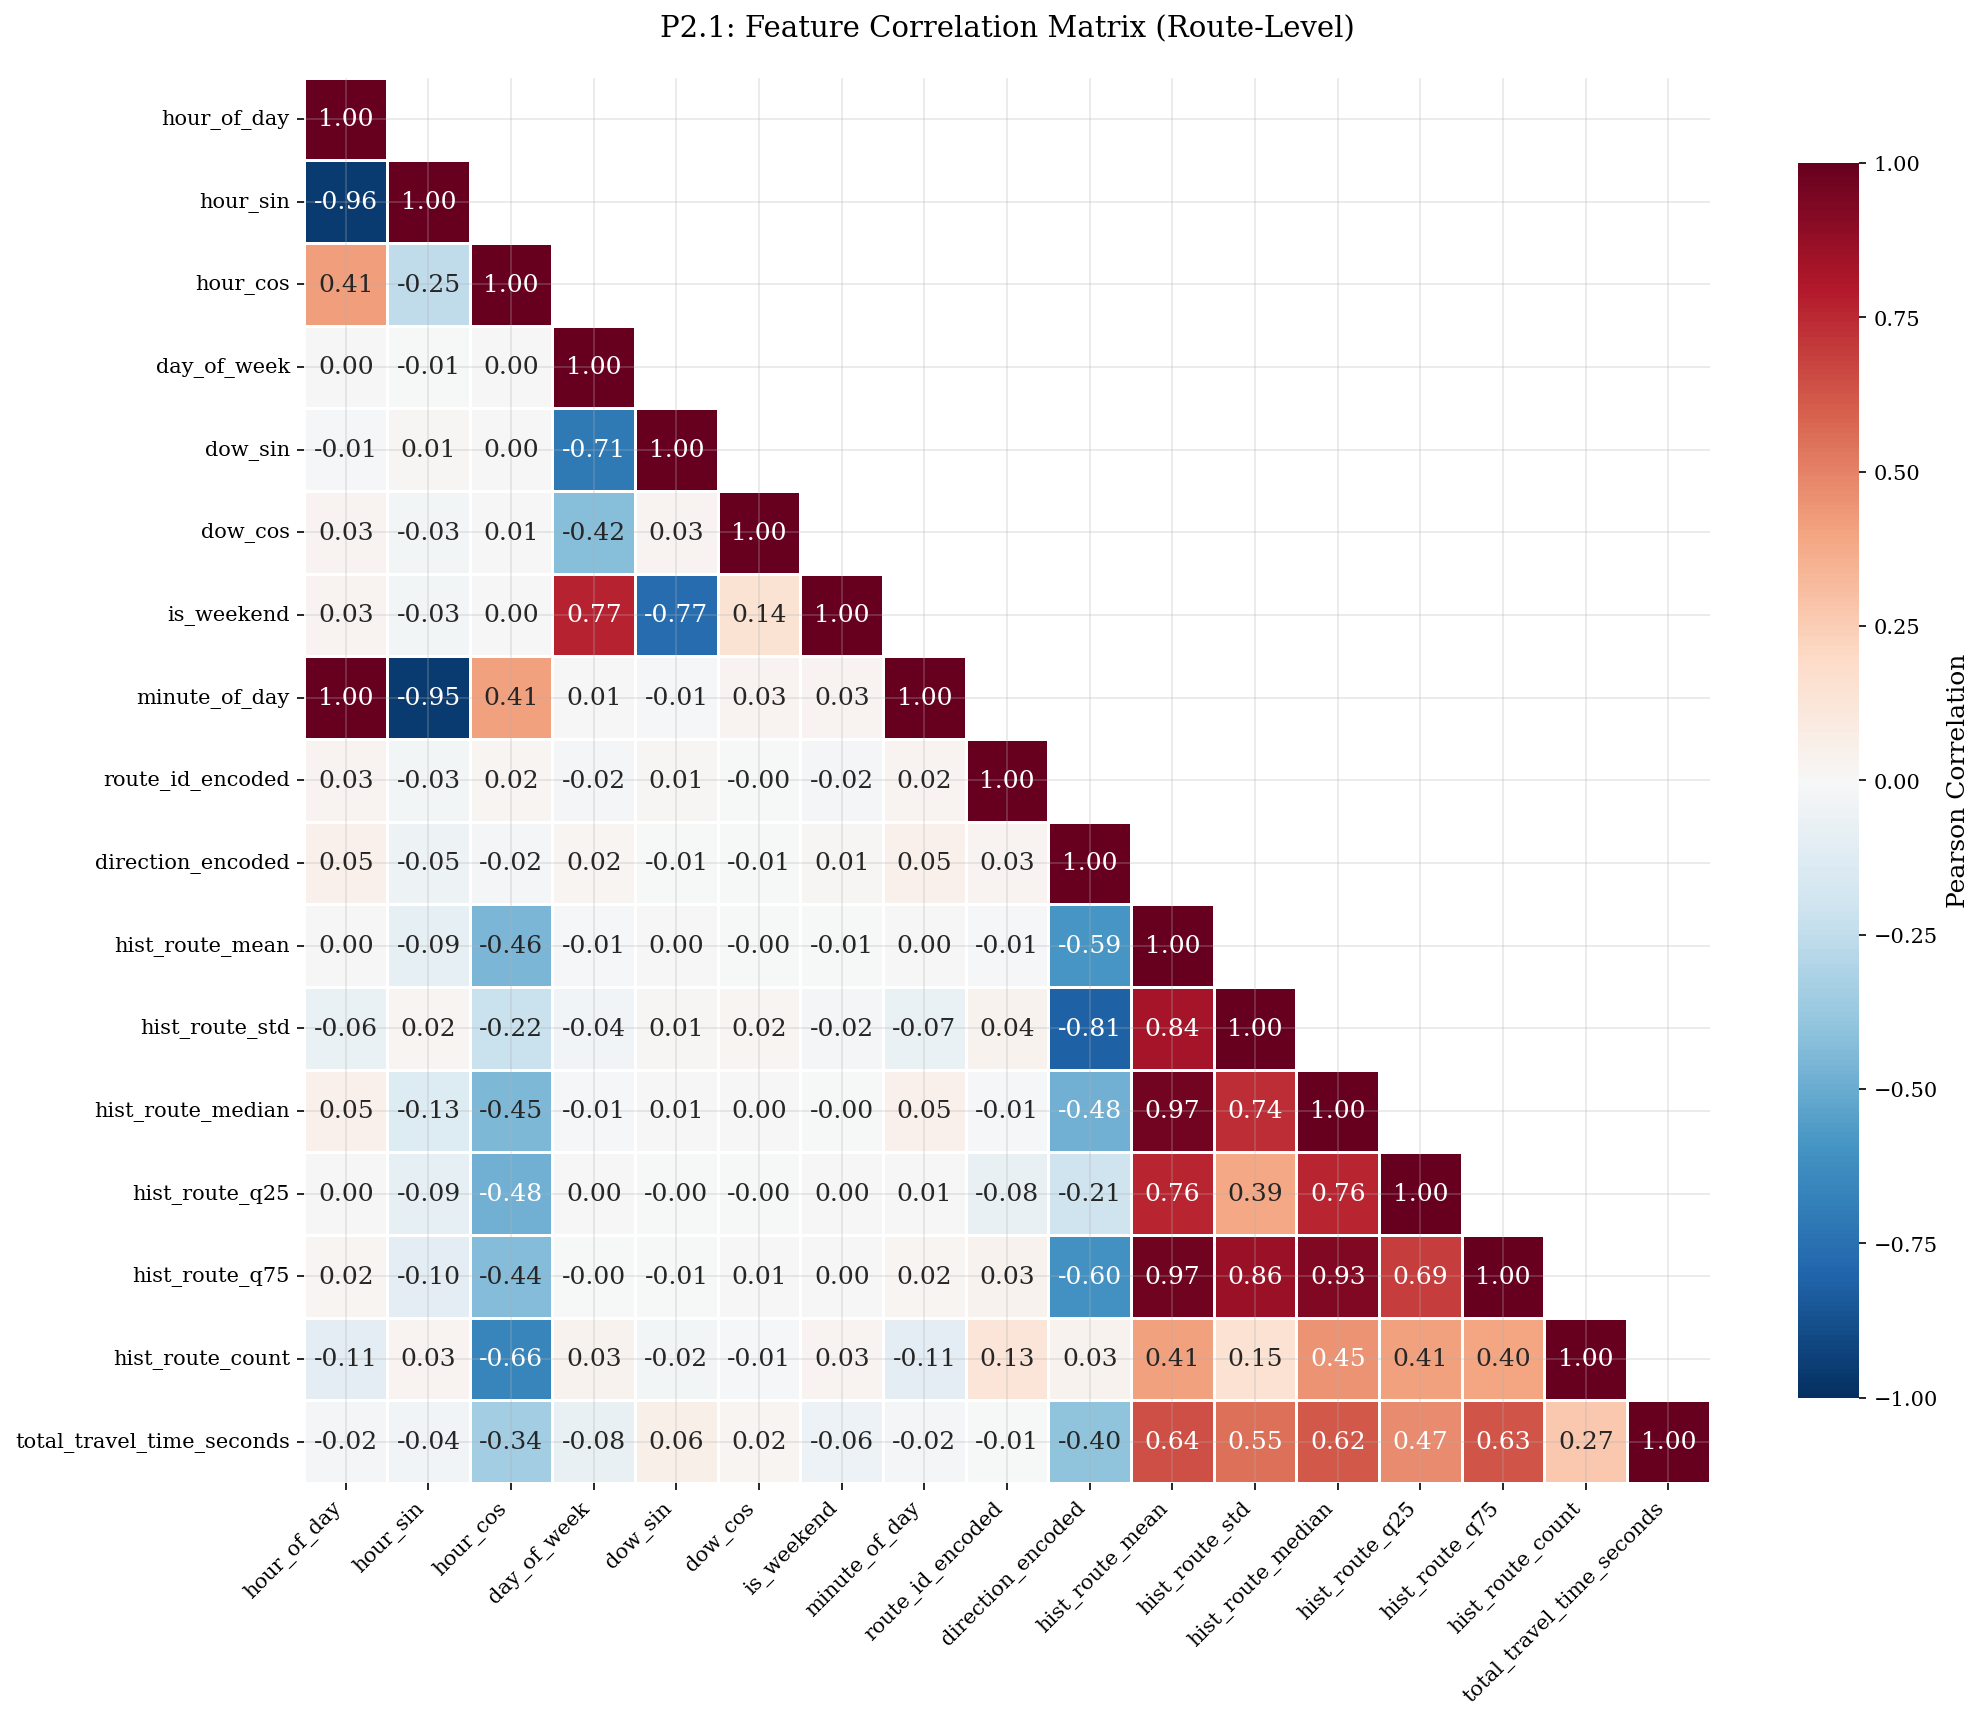


Top feature correlations with total_travel_time_seconds:
  hist_route_mean                      +0.6435
  hist_route_q75                       +0.6317
  hist_route_median                    +0.6216
  hist_route_std                       +0.5480
  hist_route_q25                       +0.4704
  direction_encoded                    -0.4004
  hour_cos                             -0.3444
  hist_route_count                     +0.2730
  day_of_week                          -0.0751
  is_weekend                           -0.0614


In [10]:
# Plot P2.1: Feature Correlation Matrix (Route-Level)
route_feature_names = get_feature_names(level='route')

# Determine the target column
target_col = 'total_travel_time_seconds'
if target_col not in route_df.columns:
    # Try alternative names
    for alt in ['total_travel_time', 'travel_time', 'total_time']:
        if alt in route_df.columns:
            target_col = alt
            break

# Select available features
available_route_features = [f for f in route_feature_names if f in route_df.columns]
corr_cols = available_route_features + [target_col]
corr_cols = [c for c in corr_cols if c in route_df.columns]

corr_matrix = route_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    ax=ax
)

ax.set_title('P2.1: Feature Correlation Matrix (Route-Level)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P2_1_feature_correlation_matrix.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P2_1_feature_correlation_matrix.pdf'), bbox_inches='tight')
plt.show()

# Print top correlations with target
if target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    print(f'\nTop feature correlations with {target_col}:')
    for feat, corr_val in target_corr.head(10).items():
        sign = '+' if corr_matrix.loc[feat, target_col] > 0 else '-'
        print(f'  {feat:35s}  {sign}{corr_val:.4f}')

---
## Plot P2.2: Feature-Target Relationships

**Thesis Connection:** These scatter plots visualize the marginal relationships between key features and the target variable. Non-linear relationships justify the use of XGBoost (a tree-based model) over linear alternatives. Strong relationships between historical features and travel time validate the feature engineering strategy.

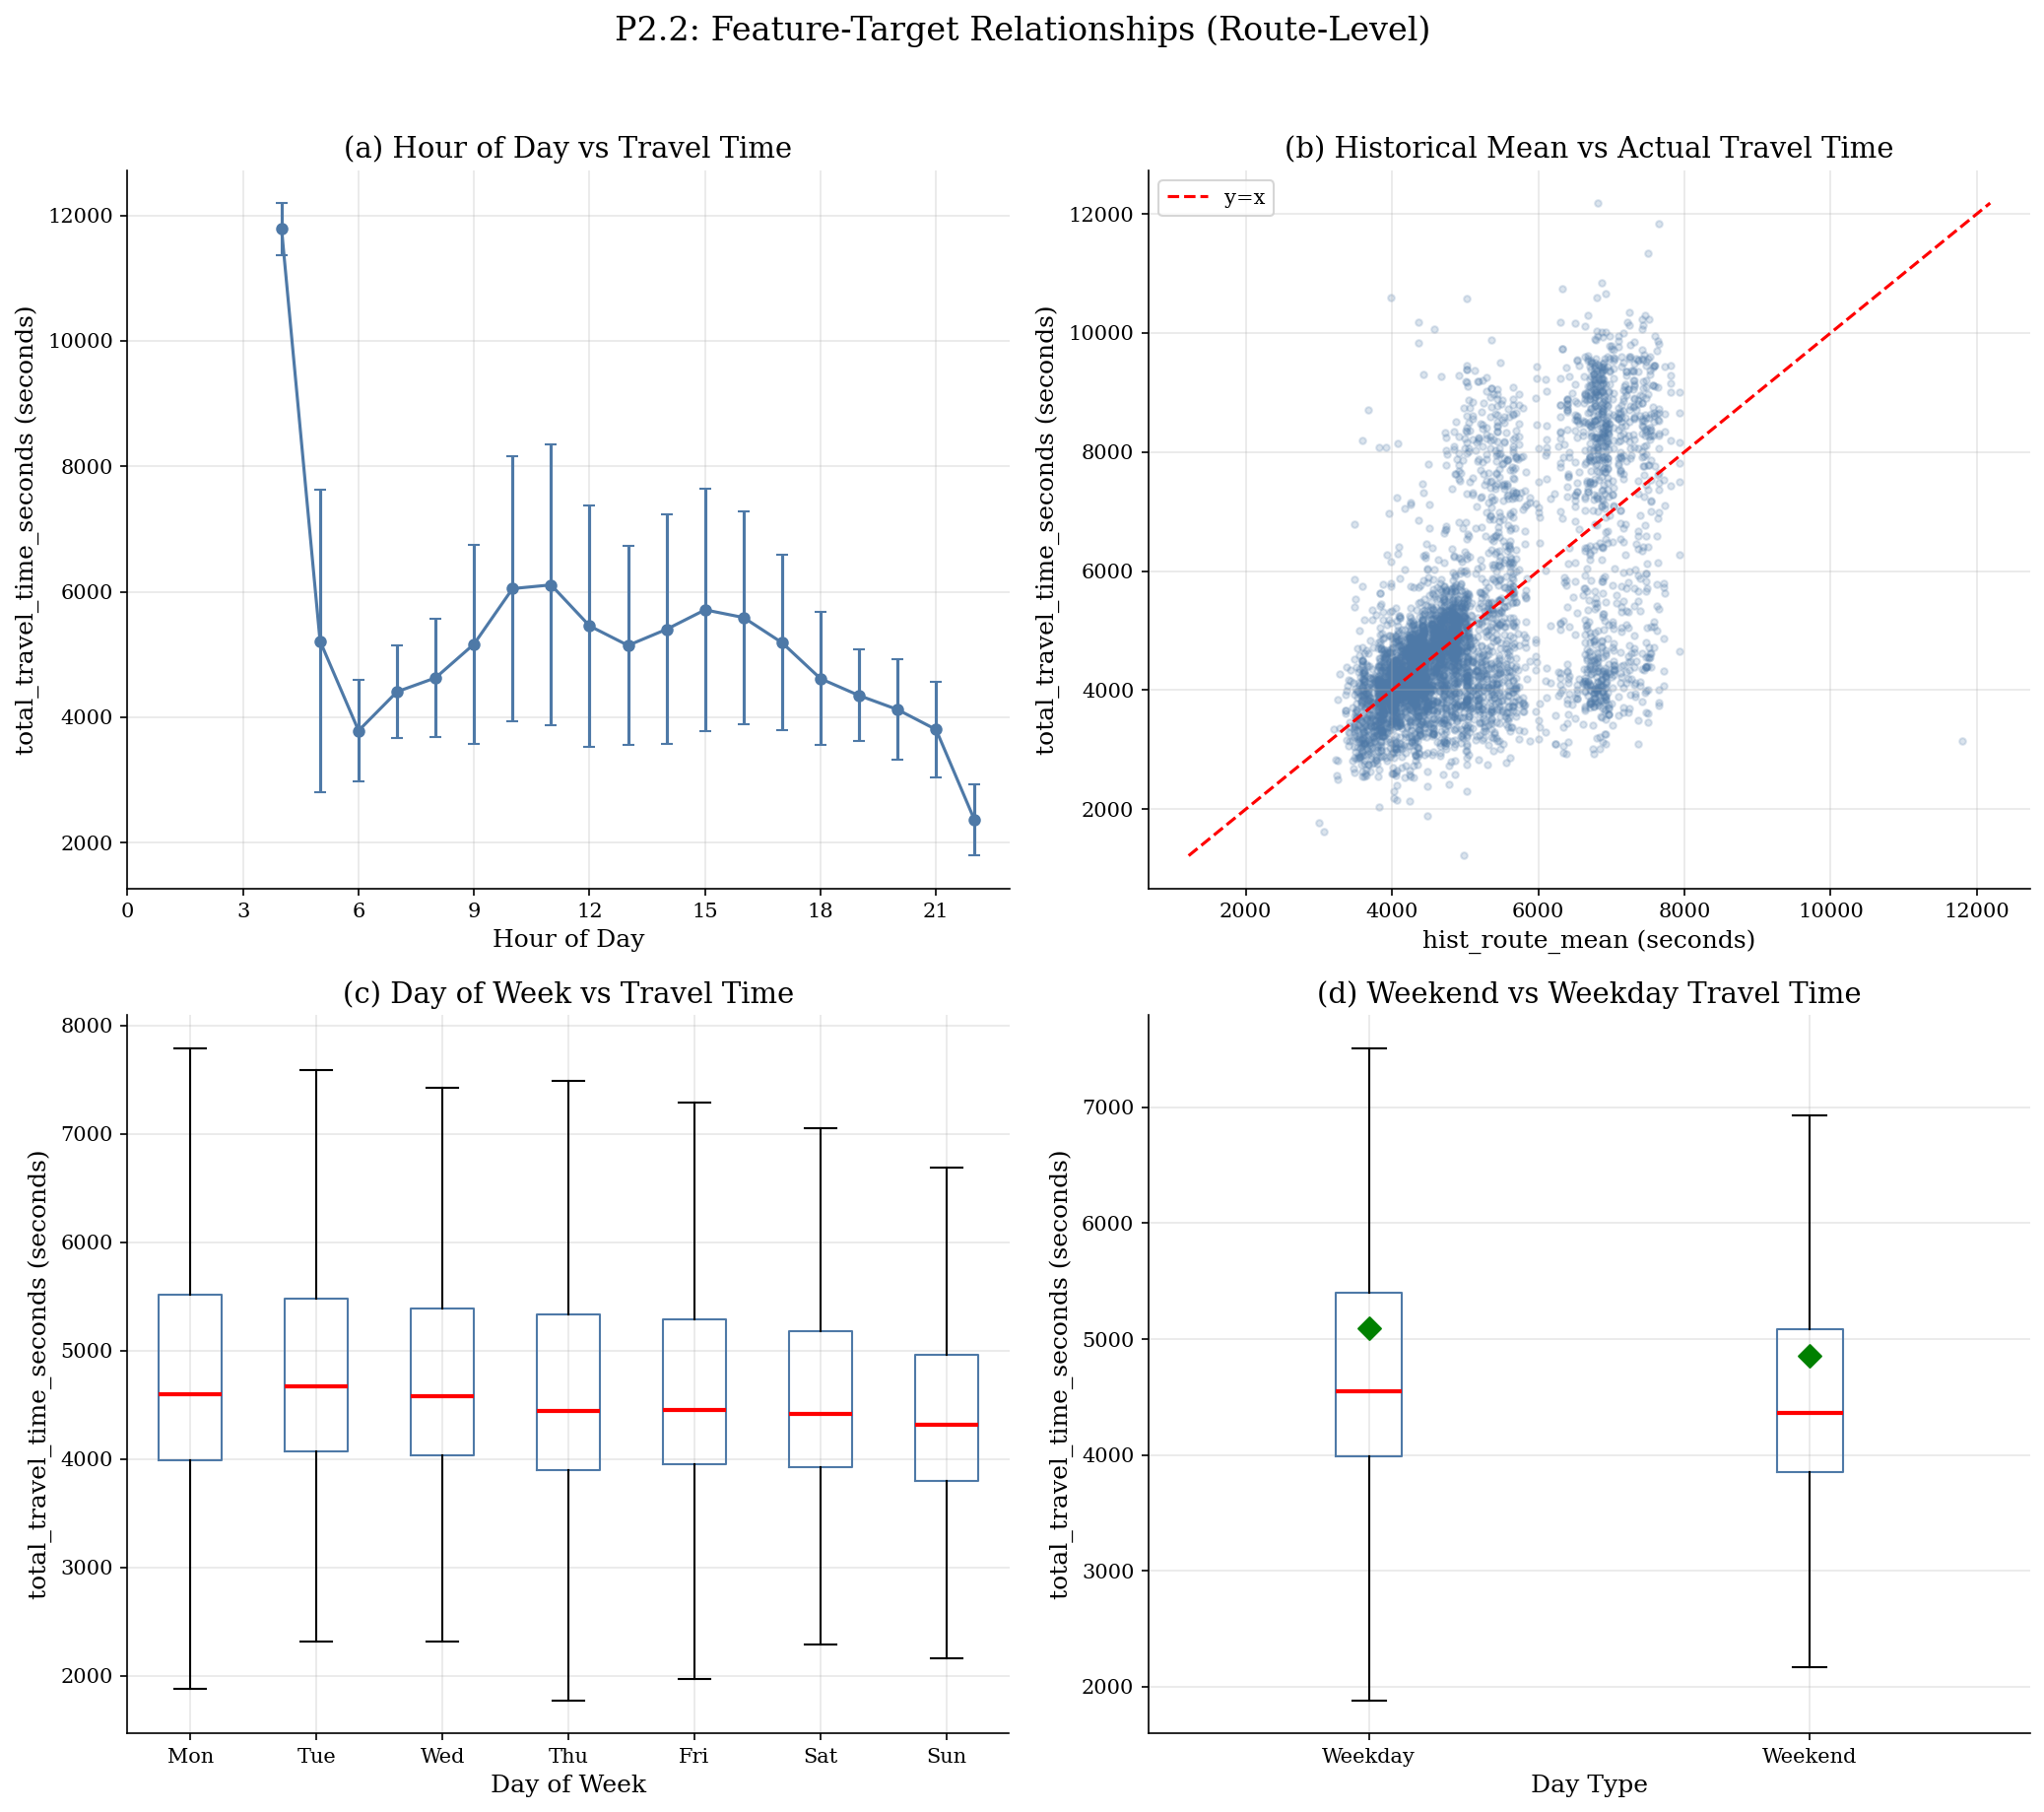


Weekday vs Weekend Travel Time:
  Weekday: mean=5090.1s, median=4552.0s, std=1717.1s
  Weekend: mean=4853.4s, median=4364.5s, std=1581.3s


In [11]:
# Plot P2.2: Feature-Target Relationships (4-panel grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Sample for scatter plots (full dataset may be too dense)
plot_sample = route_df.sample(n=min(5000, len(route_df)), random_state=42)

# Panel 1: hour_of_day vs travel_time
ax = axes[0, 0]
hourly_stats = route_df.groupby('hour_of_day')[target_col].agg(['mean', 'std']).reset_index()
ax.errorbar(hourly_stats['hour_of_day'], hourly_stats['mean'],
            yerr=hourly_stats['std'], fmt='o-', capsize=3, color='#4e79a7',
            markersize=5, linewidth=1.5)
ax.set_xlabel('Hour of Day')
ax.set_ylabel(f'{target_col} (seconds)')
ax.set_title('(a) Hour of Day vs Travel Time')
ax.set_xticks(range(0, 24, 3))

# Panel 2: hist_route_mean vs travel_time
ax = axes[0, 1]
if 'hist_route_mean' in plot_sample.columns:
    ax.scatter(plot_sample['hist_route_mean'], plot_sample[target_col],
              alpha=0.2, s=10, color='#4e79a7')
    # Add diagonal reference line
    min_val = min(plot_sample['hist_route_mean'].min(), plot_sample[target_col].min())
    max_val = max(plot_sample['hist_route_mean'].max(), plot_sample[target_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='y=x')
    ax.legend()
ax.set_xlabel('hist_route_mean (seconds)')
ax.set_ylabel(f'{target_col} (seconds)')
ax.set_title('(b) Historical Mean vs Actual Travel Time')

# Panel 3: day_of_week vs travel_time
ax = axes[1, 0]
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_data = [route_df[route_df['day_of_week'] == d][target_col].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, showfliers=False,
                boxprops=dict(color='#4e79a7'),
                medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Day of Week')
ax.set_ylabel(f'{target_col} (seconds)')
ax.set_title('(c) Day of Week vs Travel Time')

# Panel 4: is_weekend vs travel_time
ax = axes[1, 1]
weekend_data = [route_df[route_df['is_weekend'] == w][target_col].values for w in [0, 1]]
bp = ax.boxplot(weekend_data, labels=['Weekday', 'Weekend'], showfliers=False,
                boxprops=dict(color='#4e79a7'),
                medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Day Type')
ax.set_ylabel(f'{target_col} (seconds)')
ax.set_title('(d) Weekend vs Weekday Travel Time')

# Add means as diamond markers
for i, data in enumerate(weekend_data):
    ax.scatter(i + 1, np.mean(data), marker='D', color='green', s=60, zorder=5)

fig.suptitle('P2.2: Feature-Target Relationships (Route-Level)', fontsize=16, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P2_2_feature_target_relationships.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P2_2_feature_target_relationships.pdf'), bbox_inches='tight')
plt.show()

# Print summary statistics
print('\nWeekday vs Weekend Travel Time:')
for label, w in [('Weekday', 0), ('Weekend', 1)]:
    data = route_df[route_df['is_weekend'] == w][target_col]
    print(f'  {label}: mean={data.mean():.1f}s, median={data.median():.1f}s, std={data.std():.1f}s')

---
## Plot P2.3: Historical Feature Quality Over Time

**Thesis Connection (RQ1, RQ2):** This plot evaluates how well the historical mean feature tracks the actual daily mean travel time across the dataset. A good tracking relationship validates that the 7-day lookback window captures relevant patterns. The vertical line marking the train/calibration/test boundary shows whether the feature remains informative under distribution shift -- a key consideration for conformal prediction validity.

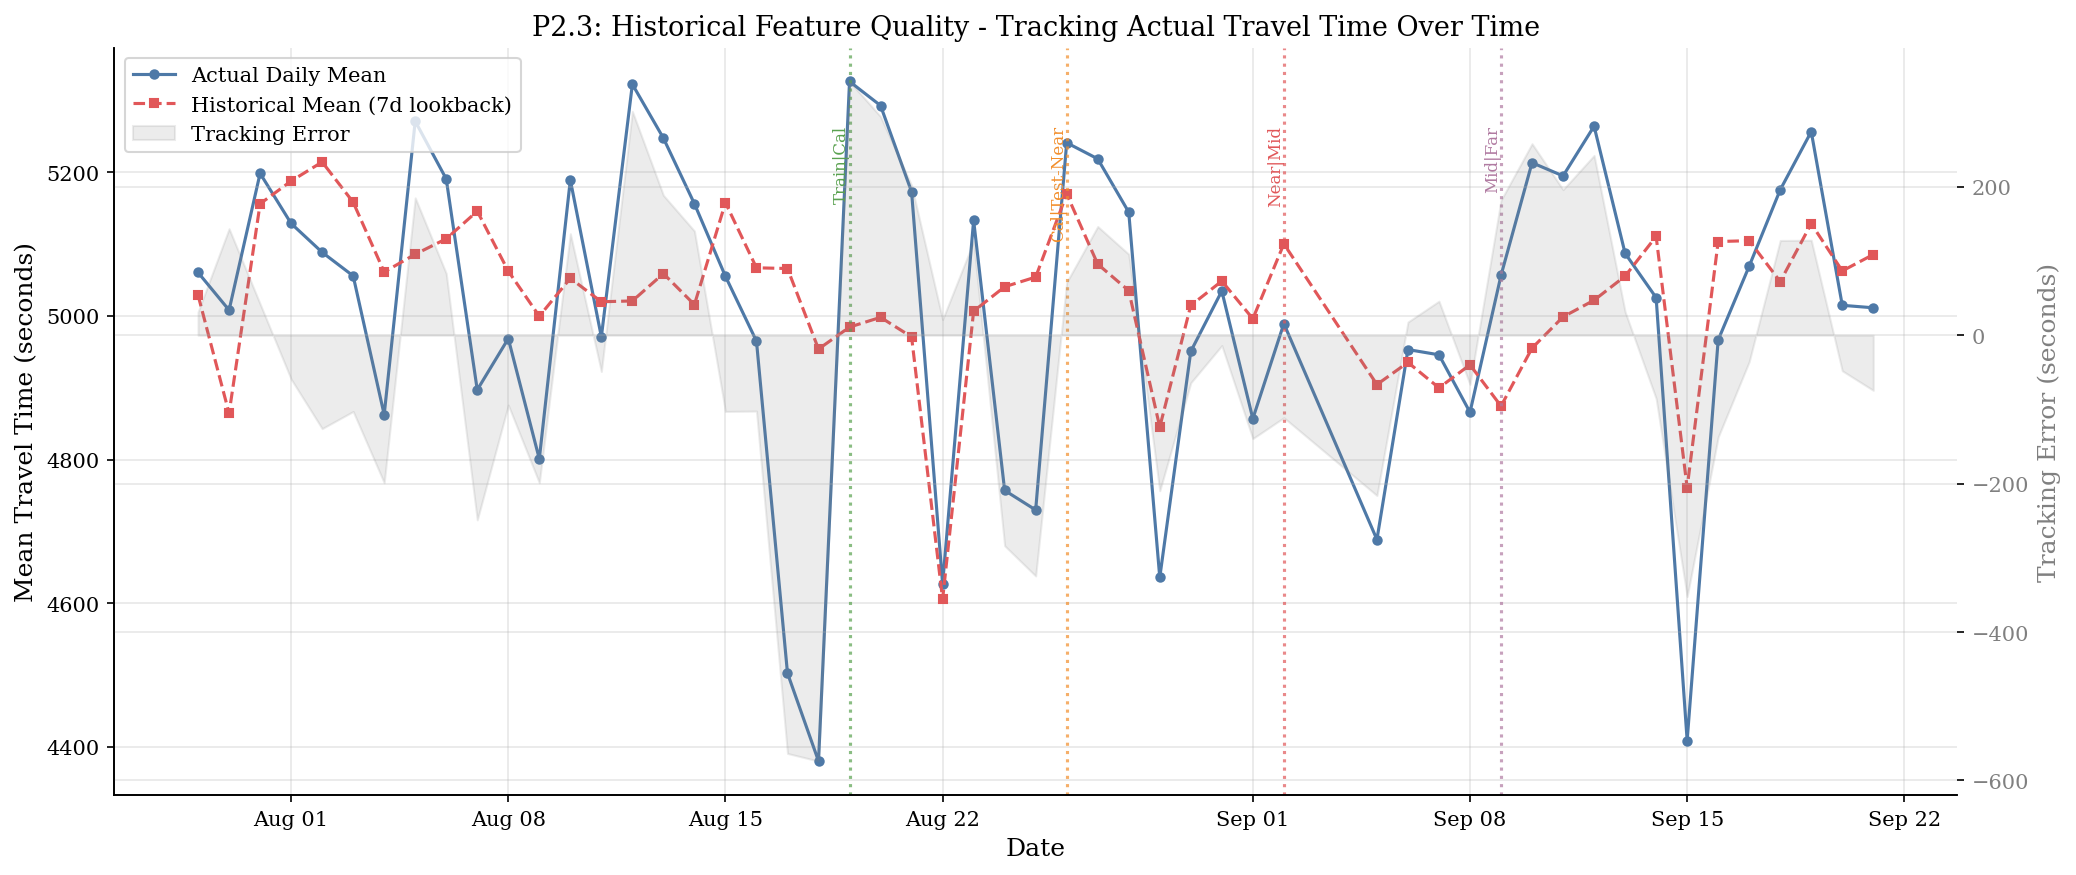


Historical Feature Tracking Quality:
  MAE:         158.09 seconds
  RMSE:        198.55 seconds
  Correlation: 0.4619


In [12]:
# Plot P2.3: Historical Feature Quality Over Time
# Label temporal periods for visualization
route_df_labeled = label_temporal_period(route_df)

# Compute daily actual and historical means
daily_actual = route_df_labeled.groupby('date')[target_col].mean().reset_index()
daily_actual.columns = ['date', 'actual_daily_mean']

daily_hist = route_df_labeled.groupby('date')['hist_route_mean'].mean().reset_index()
daily_hist.columns = ['date', 'hist_daily_mean']

daily_combined = daily_actual.merge(daily_hist, on='date')
daily_combined = daily_combined.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot actual and historical mean
ax1.plot(daily_combined['date'], daily_combined['actual_daily_mean'],
         'o-', color='#4e79a7', markersize=4, linewidth=1.5, label='Actual Daily Mean')
ax1.plot(daily_combined['date'], daily_combined['hist_daily_mean'],
         's--', color='#e15759', markersize=4, linewidth=1.5, label='Historical Mean (7d lookback)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Mean Travel Time (seconds)')

# Add temporal period boundaries
boundary_dates = [
    (pd.Timestamp('2024-08-19'), 'Train|Cal', '#59a14f'),
    (pd.Timestamp('2024-08-26'), 'Cal|Test-Near', '#f28e2b'),
    (pd.Timestamp('2024-09-02'), 'Near|Mid', '#e15759'),
    (pd.Timestamp('2024-09-09'), 'Mid|Far', '#b07aa1'),
]

for bdate, blabel, bcolor in boundary_dates:
    ax1.axvline(x=bdate, color=bcolor, linestyle=':', linewidth=1.5, alpha=0.7)
    ax1.text(bdate, ax1.get_ylim()[1] * 0.98, blabel, rotation=90,
             va='top', ha='right', fontsize=8, color=bcolor)

# Secondary axis: tracking error
ax2 = ax1.twinx()
tracking_error = daily_combined['actual_daily_mean'] - daily_combined['hist_daily_mean']
ax2.fill_between(daily_combined['date'], 0, tracking_error,
                 alpha=0.15, color='gray', label='Tracking Error')
ax2.set_ylabel('Tracking Error (seconds)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('P2.3: Historical Feature Quality - Tracking Actual Travel Time Over Time', fontsize=13)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P2_3_historical_feature_quality.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P2_3_historical_feature_quality.pdf'), bbox_inches='tight')
plt.show()

# Print tracking quality metrics
mae = np.abs(tracking_error).mean()
rmse = np.sqrt((tracking_error**2).mean())
corr = daily_combined['actual_daily_mean'].corr(daily_combined['hist_daily_mean'])
print(f'\nHistorical Feature Tracking Quality:')
print(f'  MAE:         {mae:.2f} seconds')
print(f'  RMSE:        {rmse:.2f} seconds')
print(f'  Correlation: {corr:.4f}')

---
## Table T2.1: Final Feature Set Summary

This table documents the complete feature set for both route-level and segment-level models, providing a reference for the thesis methodology chapter.

In [13]:
# Table T2.1: Final Feature Set Summary
feature_table_data = [
    # Temporal features
    {'Feature': 'hour_of_day', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Hour of day (0-23)', 'Source': 'start_time'},
    {'Feature': 'minute_of_day', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Minute of day (0-1439)', 'Source': 'start_time'},
    {'Feature': 'day_of_week', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Day of week (0=Mon, 6=Sun)', 'Source': 'date'},
    {'Feature': 'is_weekend', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Weekend indicator (0/1)', 'Source': 'day_of_week'},
    {'Feature': 'hour_sin', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Cyclical sin encoding of hour (period=24)', 'Source': 'hour_of_day'},
    {'Feature': 'hour_cos', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Cyclical cos encoding of hour (period=24)', 'Source': 'hour_of_day'},
    {'Feature': 'dow_sin', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Cyclical sin encoding of day (period=7)', 'Source': 'day_of_week'},
    {'Feature': 'dow_cos', 'Type': 'Temporal', 'Level': 'Both', 'Description': 'Cyclical cos encoding of day (period=7)', 'Source': 'day_of_week'},
    # Spatial / Route Context
    {'Feature': 'route_id_encoded', 'Type': 'Spatial', 'Level': 'Both', 'Description': 'Label-encoded route identifier', 'Source': 'route_short_name'},
    {'Feature': 'direction_encoded', 'Type': 'Spatial', 'Level': 'Both', 'Description': 'Binary direction indicator (0/1)', 'Source': 'direction'},
    # Historical - Route
    {'Feature': 'hist_route_mean', 'Type': 'Historical', 'Level': 'Route', 'Description': 'Mean travel time from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_route_std', 'Type': 'Historical', 'Level': 'Route', 'Description': 'Std dev of travel time from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_route_median', 'Type': 'Historical', 'Level': 'Route', 'Description': 'Median travel time from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_route_q25', 'Type': 'Historical', 'Level': 'Route', 'Description': '25th percentile from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_route_q75', 'Type': 'Historical', 'Level': 'Route', 'Description': '75th percentile from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_route_count', 'Type': 'Historical', 'Level': 'Route', 'Description': 'Number of observations in past 7 days', 'Source': '7d lookback'},
    # Historical - Segment
    {'Feature': 'hist_seg_mean', 'Type': 'Historical', 'Level': 'Segment', 'Description': 'Mean run time from past 7 days for segment', 'Source': '7d lookback'},
    {'Feature': 'hist_seg_std', 'Type': 'Historical', 'Level': 'Segment', 'Description': 'Std dev of run time from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_seg_median', 'Type': 'Historical', 'Level': 'Segment', 'Description': 'Median run time from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_seg_q25', 'Type': 'Historical', 'Level': 'Segment', 'Description': '25th percentile from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_seg_q75', 'Type': 'Historical', 'Level': 'Segment', 'Description': '75th percentile from past 7 days', 'Source': '7d lookback'},
    {'Feature': 'hist_seg_count', 'Type': 'Historical', 'Level': 'Segment', 'Description': 'Number of observations in past 7 days', 'Source': '7d lookback'},
    # Segment-specific spatial
    {'Feature': 'segment', 'Type': 'Spatial', 'Level': 'Segment', 'Description': 'Segment number along route', 'Source': 'raw data'},
    {'Feature': 'segment_number_normalized', 'Type': 'Spatial', 'Level': 'Segment', 'Description': 'Segment position normalized to [0, 1]', 'Source': 'segment / max_segment'},
    {'Feature': 'total_route_segments', 'Type': 'Spatial', 'Level': 'Segment', 'Description': 'Total segments in this trip route', 'Source': 'trip_id groupby'},
    # Cumulative / Trip Progress
    {'Feature': 'cumulative_time_so_far', 'Type': 'Trip Progress', 'Level': 'Segment', 'Description': 'Cumulative time of preceding segments (s)', 'Source': 'running sum'},
    {'Feature': 'segments_completed', 'Type': 'Trip Progress', 'Level': 'Segment', 'Description': 'Number of segments already traversed', 'Source': 'cumcount'},
    {'Feature': 'fraction_route_completed', 'Type': 'Trip Progress', 'Level': 'Segment', 'Description': 'Fraction of route completed (0-1)', 'Source': 'segments_completed / total'},
    # Preceding Segment Lags
    {'Feature': 'prev_seg_run_time', 'Type': 'Lag', 'Level': 'Segment', 'Description': 'Run time of segment (n-1)', 'Source': 'shift(1)'},
    {'Feature': 'prev_seg_dwell_time', 'Type': 'Lag', 'Level': 'Segment', 'Description': 'Dwell time of segment (n-1)', 'Source': 'shift(1)'},
    {'Feature': 'prev_2_seg_avg_run_time', 'Type': 'Lag', 'Level': 'Segment', 'Description': 'Avg run time of segments (n-1), (n-2)', 'Source': 'shift(1,2)'},
    {'Feature': 'prev_3_seg_avg_run_time', 'Type': 'Lag', 'Level': 'Segment', 'Description': 'Avg run time of segments (n-1) to (n-3)', 'Source': 'shift(1,2,3)'},
]

feature_table = pd.DataFrame(feature_table_data)

print('=== Table T2.1: Final Feature Set Summary ===')
display(feature_table)

# Count by level
route_features = feature_table[feature_table['Level'].isin(['Both', 'Route'])]
segment_features = feature_table[feature_table['Level'].isin(['Both', 'Segment'])]
print(f'\nRoute-level model features:   {len(route_features)}')
print(f'Segment-level model features: {len(segment_features)}')

# Count by type
print(f'\nFeatures by type:')
for ftype, count in feature_table['Type'].value_counts().items():
    print(f'  {ftype}: {count}')

# Save as LaTeX
latex_table = feature_table.to_latex(
    index=False,
    caption='Feature set summary for route-level and segment-level models. '
            'Historical features use strict 7-day past-only lookback to prevent data leakage.',
    label='tab:feature_summary',
    column_format='llllp{5cm}l'
)
with open(os.path.join(TABLE_DIR, 'T2_1_feature_summary.tex'), 'w') as f:
    f.write(latex_table)
print(f'\nLaTeX table saved to {os.path.join(TABLE_DIR, "T2_1_feature_summary.tex")}')

=== Table T2.1: Final Feature Set Summary ===


,Feature,Type,Level,Description,Source
0,hour_of_day,Temporal,Both,Hour of day (0-23),start_time
1,minute_of_day,Temporal,Both,Minute of day (0-1439),start_time
2,day_of_week,Temporal,Both,"Day of week (0=Mon, 6=Sun)",date
3,is_weekend,Temporal,Both,Weekend indicator (0/1),day_of_week
4,hour_sin,Temporal,Both,Cyclical sin encoding of hour (period=24),hour_of_day
5,hour_cos,Temporal,Both,Cyclical cos encoding of hour (period=24),hour_of_day
6,dow_sin,Temporal,Both,Cyclical sin encoding of day (period=7),day_of_week
7,dow_cos,Temporal,Both,Cyclical cos encoding of day (period=7),day_of_week
8,route_id_encoded,Spatial,Both,Label-encoded route identifier,route_short_name
9,direction_encoded,Spatial,Both,Binary direction indicator (0/1),direction



Route-level model features:   16
Segment-level model features: 26

Features by type:
  Historical: 12
  Temporal: 8
  Spatial: 5
  Lag: 4
  Trip Progress: 3

LaTeX table saved to ../outputs/tables/T2_1_feature_summary.tex


---
## 9. Save Feature-Engineered Data

We save the final feature-engineered datasets as parquet files for efficient loading in subsequent phases (Phase 3: Model Training, Phase 4: Conformal Prediction Experiments).

In [14]:
# Save feature-engineered datasets
route_output_path = os.path.join(PROCESSED_DIR, 'route_features.parquet')
segment_output_path = os.path.join(PROCESSED_DIR, 'segment_features.parquet')

os.makedirs(PROCESSED_DIR, exist_ok=True)

route_df.to_parquet(route_output_path, index=False, engine='pyarrow')
segment_df.to_parquet(segment_output_path, index=False, engine='pyarrow')

print('Feature-engineered data saved successfully.')
print(f'\n=== Route-Level Features ===')
print(f'  Path:     {os.path.abspath(route_output_path)}')
print(f'  Shape:    {route_df.shape[0]:,} rows x {route_df.shape[1]} columns')
print(f'  Features: {len(get_feature_names("route"))} model features')
print(f'  Columns:  {list(route_df.columns)}')

print(f'\n=== Segment-Level Features ===')
print(f'  Path:     {os.path.abspath(segment_output_path)}')
print(f'  Shape:    {segment_df.shape[0]:,} rows x {segment_df.shape[1]} columns')
print(f'  Features: {len(get_feature_names("segment"))} model features')
print(f'  Columns:  {list(segment_df.columns)}')

# Final NaN audit
print(f'\n=== Final NaN Audit ===')
route_nans = route_df[get_feature_names('route')].isnull().sum()
route_nans_nonzero = route_nans[route_nans > 0]
if len(route_nans_nonzero) == 0:
    print('  Route-level: No NaN values in any model features.')
else:
    print(f'  Route-level NaN features:')
    print(route_nans_nonzero)

seg_feature_names = [f for f in get_feature_names('segment') if f in segment_df.columns]
seg_nans = segment_df[seg_feature_names].isnull().sum()
seg_nans_nonzero = seg_nans[seg_nans > 0]
if len(seg_nans_nonzero) == 0:
    print('  Segment-level: No NaN values in any model features.')
else:
    print(f'  Segment-level NaN features:')
    print(seg_nans_nonzero)

Feature-engineered data saved successfully.

=== Route-Level Features ===
  Path:     /Users/korayduzgun/Master/Courses/FinalProject/ImplementationV1/outputs/processed_data/route_features.parquet
  Shape:    19,614 rows x 31 columns
  Features: 16 model features
  Columns:  ['trip_id', 'total_run_time_seconds', 'total_dwell_time_seconds', 'num_segments', 'direction', 'date', 'route_id', 'route_short_name', 'deviceid', 'departure_time', 'total_travel_time_seconds', 'route_dir', 'temporal_period', 'hour_of_day', 'minute_of_day', 'day_of_week', 'is_weekend', 'time_period', 'week_number', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'hist_route_mean', 'hist_route_std', 'hist_route_median', 'hist_route_q25', 'hist_route_q75', 'hist_route_count', 'route_id_encoded', 'direction_encoded']

=== Segment-Level Features ===
  Path:     /Users/korayduzgun/Master/Courses/FinalProject/ImplementationV1/outputs/processed_data/segment_features.parquet
  Shape:    747,798 rows x 47 columns
  Features: 2

---
## Phase 2 Summary

### Feature Engineering Completed

We have constructed the complete feature set for both route-level and segment-level uncertainty-aware bus ETA prediction:

| Category | Route-Level | Segment-Level | Description |
|----------|:-----------:|:-------------:|-------------|
| Temporal | 8 | 8 | Hour, day-of-week, weekend, cyclical encodings |
| Historical Statistics | 6 | 6 | 7-day lookback mean, std, median, quantiles, count |
| Spatial / Route Context | 2 | 5 | Route/direction encoding, segment position |
| Trip Progress | 0 | 3 | Cumulative time, segments completed, fraction done |
| Preceding Segment Lags | 0 | 4 | Lag-1, lag-2, lag-3 run/dwell times |
| **Total** | **~16** | **~26** | |

### Key Design Decisions

1. **Temporal integrity**: All historical features use strict past-only lookback ($[t-7d, t)$). No future information leaks into any feature, preserving the validity of conformal prediction coverage guarantees.

2. **Global mean fallback**: For the first week of the dataset where fewer than 7 days of history exist, global mean statistics are used as a conservative fallback. The `hist_*_count` feature encodes this reduced confidence.

3. **Lag feature imputation**: First-segment lag features are imputed with column means, providing a neutral default that does not introduce directional bias.

4. **Feature correlation**: Historical mean features show strong positive correlation with the target (validating the lookback approach), while cyclical encodings capture complementary information about periodic patterns.

5. **Tracking quality**: The historical mean feature tracks the actual daily mean travel time closely, with tracking errors remaining small even across the train/calibration/test boundary.

### Next Steps

Phase 3 will use these feature-engineered datasets to train XGBoost base models for both route-level and segment-level prediction, then apply conformal prediction to generate uncertainty intervals.